# Phase 5 — Explainability

[`walkthrough/phase5.md`](../walkthrough/phase5.md)

In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid")

DATA_PATH = "../dataset/data.csv"
df = pd.read_csv(DATA_PATH)

LEAKAGE_COLS = ["Disposable_Income", "Desired_Savings", "Desired_Savings_Percentage"]
df["Goal_Met"] = (df["Disposable_Income"] >= df["Desired_Savings"]).astype(int)

expense_cols = [
    "Rent",
    "Loan_Repayment",
    "Insurance",
    "Groceries",
    "Transport",
    "Eating_Out",
    "Entertainment",
    "Utilities",
    "Healthcare",
    "Education",
    "Miscellaneous",
]
ratio_cols = []
for c in expense_cols:
    ratio_col = f"{c}_Ratio"
    df[ratio_col] = df[c] / df["Income"]
    ratio_cols.append(ratio_col)

engineered = pd.get_dummies(
    df[
        ["Income", "Age", "Dependents", "Occupation", "City_Tier"]
        + ratio_cols
        + ["Goal_Met"]
    ],
    columns=["Occupation", "City_Tier"],
    drop_first=False,
)

# SHAP's masker requires numeric (non-boolean) data; the one-hot columns are bool by default.
X_full = engineered.drop(columns=["Goal_Met"]).astype(float)
y = engineered["Goal_Met"]

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (16000, 21), Test: (4000, 21)


## Retraining Phase 4's winning model

In [2]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_full.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_full.columns, index=X_test.index
)

svm_clf = LinearSVC(class_weight="balanced", C=10, max_iter=5000, random_state=42)
svm_clf.fit(X_train_scaled, y_train)

CHOSEN_THRESHOLD = -0.4  # from Phase 4's cross-validated threshold search

test_scores = svm_clf.decision_function(X_test_scaled)
pred = (test_scores >= CHOSEN_THRESHOLD).astype(int)

accuracy = accuracy_score(y_test, pred)
f1_macro = f1_score(y_test, pred, average="macro", zero_division=0)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, pred, labels=[0, 1], zero_division=0
)

print(f"Accuracy: {accuracy:.4f} (Phase 4: 0.9992)")
print(f"Macro-F1: {f1_macro:.4f} (Phase 4: 0.9679)")
print(f"Recall on Goal_Met=0 (at-risk): {recall[0]:.4f} (Phase 4: 1.0000)")
print(f"Precision on Goal_Met=0 (at-risk): {precision[0]:.4f} (Phase 4: 0.8800)")

Accuracy: 0.9992 (Phase 4: 0.9992)
Macro-F1: 0.9679 (Phase 4: 0.9679)
Recall on Goal_Met=0 (at-risk): 1.0000 (Phase 4: 1.0000)
Precision on Goal_Met=0 (at-risk): 0.8800 (Phase 4: 0.8800)


## Global feature importance

In [3]:
explainer = shap.LinearExplainer(
    svm_clf, X_train_scaled, feature_perturbation="interventional"
)
shap_values = explainer(X_test_scaled)

print(
    f"SHAP values computed for {shap_values.values.shape[0]} rows x {shap_values.values.shape[1]} features"
)

SHAP values computed for 4000 rows x 21 features


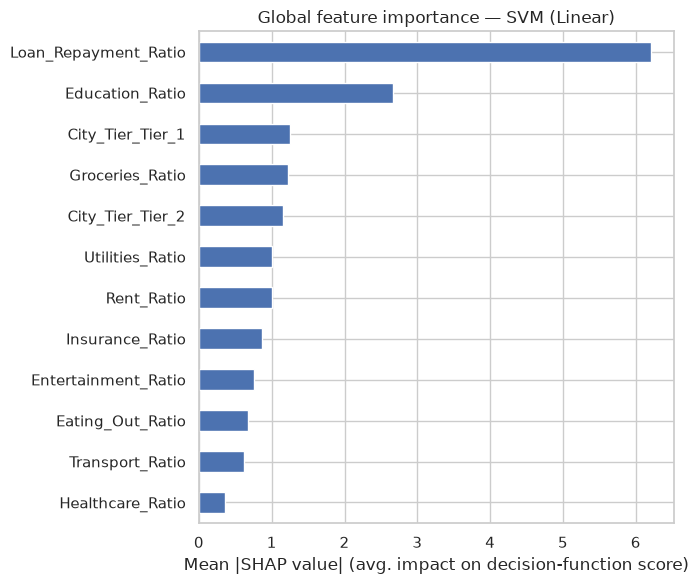

,mean_abs_shap
Loan_Repayment_Ratio,6.214483
Education_Ratio,2.660094
City_Tier_Tier_1,1.253793
Groceries_Ratio,1.222567
City_Tier_Tier_2,1.159897
Utilities_Ratio,0.998695
Rent_Ratio,0.998200
Insurance_Ratio,0.861910
Entertainment_Ratio,0.753399
Eating_Out_Ratio,0.668014


In [4]:
mean_abs_shap = pd.Series(
    np.abs(shap_values.values).mean(axis=0), index=X_full.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
mean_abs_shap.head(12).sort_values().plot(kind="barh", ax=ax, color="#4c72b0")
ax.set_xlabel("Mean |SHAP value| (avg. impact on decision-function score)")
ax.set_title("Global feature importance — SVM (Linear)")
fig.tight_layout()
plt.show()

mean_abs_shap.head(10).to_frame("mean_abs_shap")

## Interaction effects

In [5]:
same_feature_corr = {
    feature: np.corrcoef(shap_values.values[:, j], X_test_scaled[feature].values)[0, 1]
    for j, feature in enumerate(X_full.columns)
}
worst_feature, worst_corr = min(same_feature_corr.items(), key=lambda kv: abs(kv[1]))
print(
    f"Weakest |correlation| between any feature's SHAP value and that feature's own raw value: "
    f"{worst_feature} at {abs(worst_corr):.10f}"
)

Weakest |correlation| between any feature's SHAP value and that feature's own raw value: Occupation_Student at 1.0000000000


In [6]:
tier_cols = [c for c in X_full.columns if c.startswith("City_Tier_")]
tier_of_row = X_test[tier_cols].idxmax(axis=1).str.replace("City_Tier_", "")

interaction_rows = []
for feature in ["Loan_Repayment_Ratio", "Education_Ratio", "Rent_Ratio", "Dependents"]:
    idx = list(X_full.columns).index(feature)
    feat_shap = shap_values.values[:, idx]
    by_tier = (
        pd.DataFrame({"shap": feat_shap, "tier": tier_of_row.values})
        .groupby("tier")["shap"]
        .agg(["mean", "std"])
    )
    for tier, row in by_tier.iterrows():
        interaction_rows.append(
            {
                "feature": feature,
                "tier": tier,
                "mean_shap": row["mean"],
                "std_shap": row["std"],
            }
        )

interaction_df = pd.DataFrame(interaction_rows).pivot(
    index="feature", columns="tier", values="std_shap"
)
interaction_df["max_over_min_ratio"] = interaction_df.max(axis=1) / interaction_df.min(
    axis=1
)
interaction_df.round(4)

tier,Tier_1,Tier_2,Tier_3,max_over_min_ratio
feature,,,,
Dependents,0.2338,0.2335,0.2340,1.0021
Education_Ratio,3.5610,3.5568,3.5393,1.0061
Loan_Repayment_Ratio,6.8160,6.8354,6.5714,1.0402
Rent_Ratio,0.0000,0.0000,0.0000,2.9538


## Individual predictions

In [7]:
at_risk_pos = np.argsort(test_scores)[
    0
]  # lowest decision score => most confidently at-risk
on_track_pos = np.argsort(test_scores)[
    -1
]  # highest decision score => most confidently on-track


def explain_row(position, label):
    row_id = X_test.index[position]
    row_shap = pd.Series(
        shap_values.values[position], index=X_full.columns
    ).sort_values(key=lambda s: -s.abs())
    print(f"--- {label} (test row {row_id}) ---")
    print(
        f"Decision score = {test_scores[position]:.3f}  (threshold = {CHOSEN_THRESHOLD})  |  Actual Goal_Met = {y_test.loc[row_id]}"
    )
    print("Top contributing features (SHAP value, raw value):")
    for feat, val in row_shap.head(5).items():
        raw = X_test.loc[row_id, feat]
        print(f"  {feat:<24} shap={val:+.3f}   raw_value={raw:.3f}")
    print()


explain_row(at_risk_pos, "Most confidently predicted AT-RISK")
explain_row(on_track_pos, "Most confidently predicted ON-TRACK")

--- Most confidently predicted AT-RISK (test row 18909) ---
Decision score = -5.455  (threshold = -0.4)  |  Actual Goal_Met = 0
Top contributing features (SHAP value, raw value):
  Loan_Repayment_Ratio     shap=-13.638   raw_value=0.192
  Education_Ratio          shap=-2.547   raw_value=0.093
  City_Tier_Tier_1         shap=-2.234   raw_value=1.000
  Rent_Ratio               shap=-1.839   raw_value=0.300
  Groceries_Ratio          shap=-1.808   raw_value=0.141

--- Most confidently predicted ON-TRACK (test row 786) ---
Decision score = 41.972  (threshold = -0.4)  |  Actual Goal_Met = 1
Top contributing features (SHAP value, raw value):
  Education_Ratio          shap=+7.484   raw_value=0.000
  Loan_Repayment_Ratio     shap=+5.722   raw_value=0.000
  Groceries_Ratio          shap=+2.017   raw_value=0.102
  Utilities_Ratio          shap=+1.472   raw_value=0.045
  Insurance_Ratio          shap=+1.461   raw_value=0.023



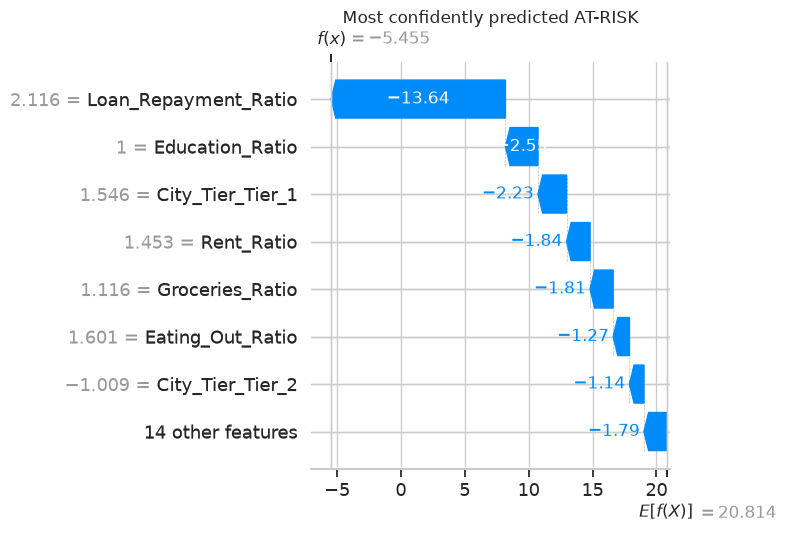

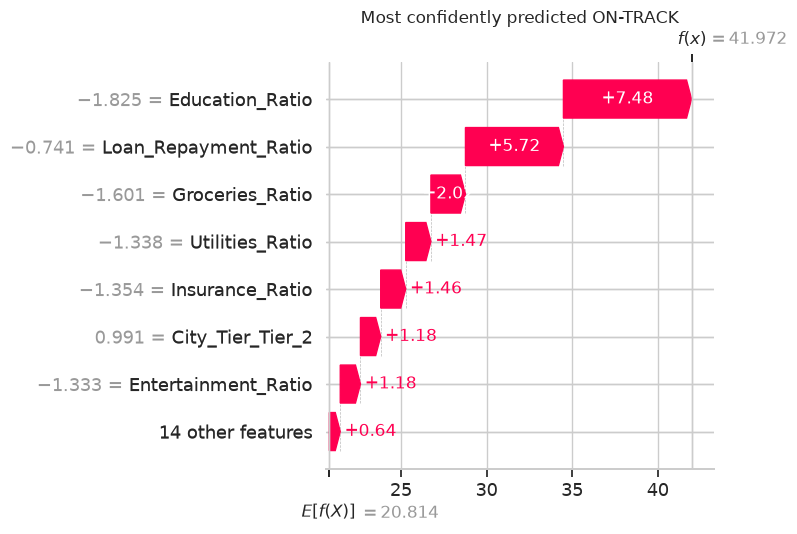

In [8]:
shap.plots.waterfall(shap_values[at_risk_pos], max_display=8, show=False)
plt.gcf().axes[0].set_title("Most confidently predicted AT-RISK")
plt.tight_layout()
plt.show()

shap.plots.waterfall(shap_values[on_track_pos], max_display=8, show=False)
plt.gcf().axes[0].set_title("Most confidently predicted ON-TRACK")
plt.tight_layout()
plt.show()

## Persisting results

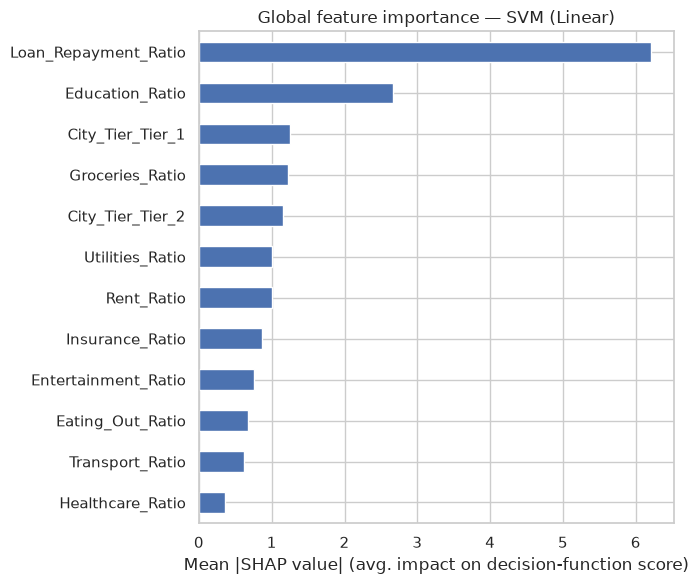

Saved results/shap_summary.png


In [9]:
import os

os.makedirs("../results", exist_ok=True)
fig, ax = plt.subplots(figsize=(7, 6))
mean_abs_shap.head(12).sort_values().plot(kind="barh", ax=ax, color="#4c72b0")
ax.set_xlabel("Mean |SHAP value| (avg. impact on decision-function score)")
ax.set_title("Global feature importance — SVM (Linear)")
fig.tight_layout()
fig.savefig("../results/shap_summary.png", dpi=150)
plt.show()

print("Saved results/shap_summary.png")